<a href="https://colab.research.google.com/github/vishakha711/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Credit Card Fraud Detection**

### Required Libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve
import joblib

### Load Dataset

In [ ]:
df = pd.read_csv('/content/creditcard.csv.zip')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
#Checking the the number of missing values
df.isnull().sum().sum()

np.int64(0)

In [ ]:
#Distribution of legit transaction and fraudulent transaction
df['Class'].value_counts()

,count
Class,
0,284315
1,492


### Data Preprocessing

0-->Normal Transaction
    1-->Fraudulent Transaction

In [ ]:
# Create a scaler object
scaler = StandardScaler()

# Create a copy of the dataframe to avoid changing the original
df_scaled = df.copy()

# Scale the 'Amount' and 'Time' columns
df_scaled['scaled_Amount'] = scaler.fit_transform(df_scaled['Amount'].values.reshape(-1, 1))
df_scaled['scaled_Time'] = scaler.fit_transform(df_scaled['Time'].values.reshape(-1, 1))

# Drop the original 'Time' and 'Amount' columns
df_scaled.drop(['Time', 'Amount'], axis=1, inplace=True)

### Data Analysis & Visualization

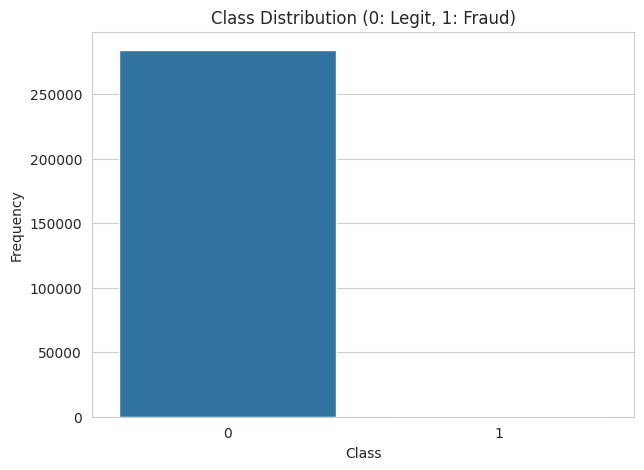

In [ ]:
# Set the style
sns.set_style('whitegrid')
# Plot the class distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Legit, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Separate Legit and Fraud transactions
legit = df_scaled[df_scaled.Class == 0]
fraud = df_scaled[df_scaled.Class == 1]
print("\nLegit shape:", legit.shape, "| Fraud shape:", fraud.shape)


Legit shape: (284315, 31) | Fraud shape: (492, 31)


###Handling Class Imbalance using SMOTE

In [ ]:
### Apply SMOTE for balancing the dataset

X = df_scaled.drop(columns='Class', axis=1)
Y = df_scaled['Class']

sm = SMOTE(random_state=42)
X_res, Y_res = sm.fit_resample(X, Y)

print("Before SMOTE:", Y.value_counts())
print("After SMOTE:", Y_res.value_counts())


Before SMOTE: Class
0    284315
1       492
Name: count, dtype: int64
After SMOTE: Class
0    284315
1    284315
Name: count, dtype: int64


### Split the data into train data and test data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_res, Y_res, test_size=0.2, stratify=Y_res, random_state=2)

In [ ]:
print(X_res.shape, X_train.shape, X_test.shape)

(568630, 30) (454904, 30) (113726, 30)


### Model Training

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, Y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:49:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
models = {'Logistic Regression': lr, 'XGBoost': xgb}

### Model Evaluation

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n🔹 {name}")
    print("Accuracy:", accuracy_score(Y_test, y_pred))
    print("Precision:", precision_score(Y_test, y_pred))
    print("Recall:", recall_score(Y_test, y_pred))
    print("F1 Score:", f1_score(Y_test, y_pred))
    print("AUC-ROC:", roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]))



🔹 Logistic Regression
Accuracy: 0.948261611241053
Precision: 0.97412622533063
Recall: 0.9209855266166048
F1 Score: 0.946810818628869
AUC-ROC: 0.9892920653907349

🔹 XGBoost
Accuracy: 0.9996658635668185
Precision: 0.9993321734240171
Recall: 1.0
F1 Score: 0.9996659751766815
AUC-ROC: 0.9999943809934809


### Confusion Matrix (XGBoost)

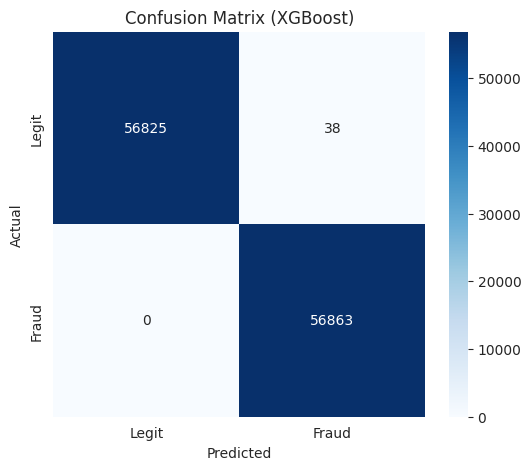


Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



In [ ]:
y_pred = xgb.predict(X_test)
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (XGBoost)')
plt.show()

# Classification Report
print("\nClassification Report (XGBoost):")
print(classification_report(Y_test, y_pred))

### ROC Curve Comparison

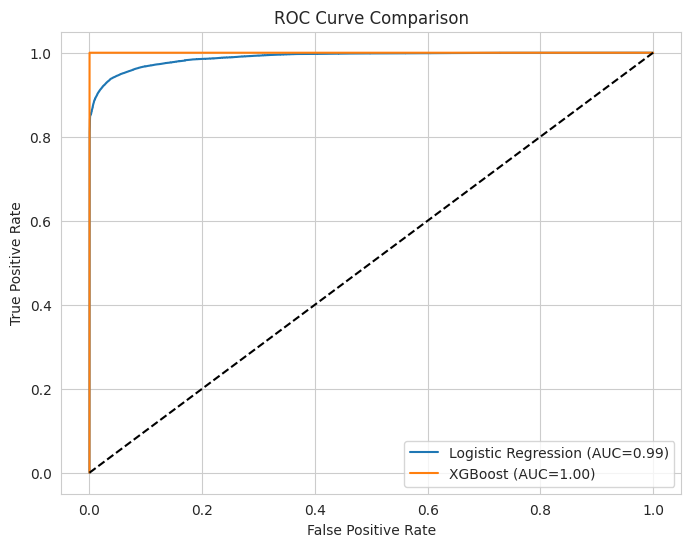

In [ ]:

plt.figure(figsize=(8,6))
for name, model in models.items():
    fpr, tpr, _ = roc_curve(Y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Transaction Amount Distribution

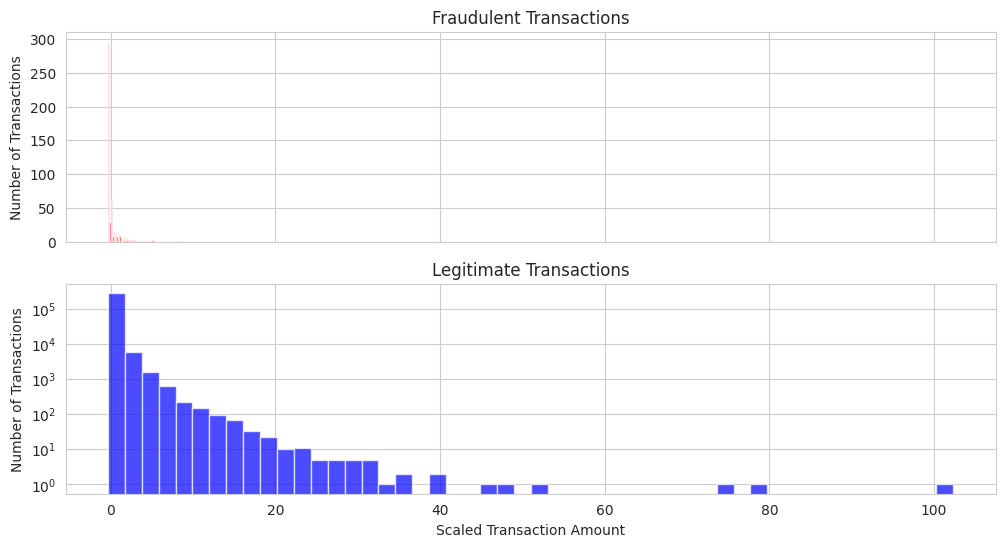

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 6))

# Plotting the scaled amount for fraud transactions
ax1.hist(fraud.scaled_Amount, bins=50, color='red', alpha=0.7)
ax1.set_title('Fraudulent Transactions')
ax1.set_ylabel('Number of Transactions')

# Plotting the scaled amount for legit transactions
ax2.hist(legit.scaled_Amount, bins=50, color='blue', alpha=0.7)
ax2.set_title('Legitimate Transactions')
ax2.set_xlabel('Scaled Transaction Amount') # Label updated here
ax2.set_ylabel('Number of Transactions')

plt.yscale('log')
plt.show()

### Feature Importance (XGBoost)

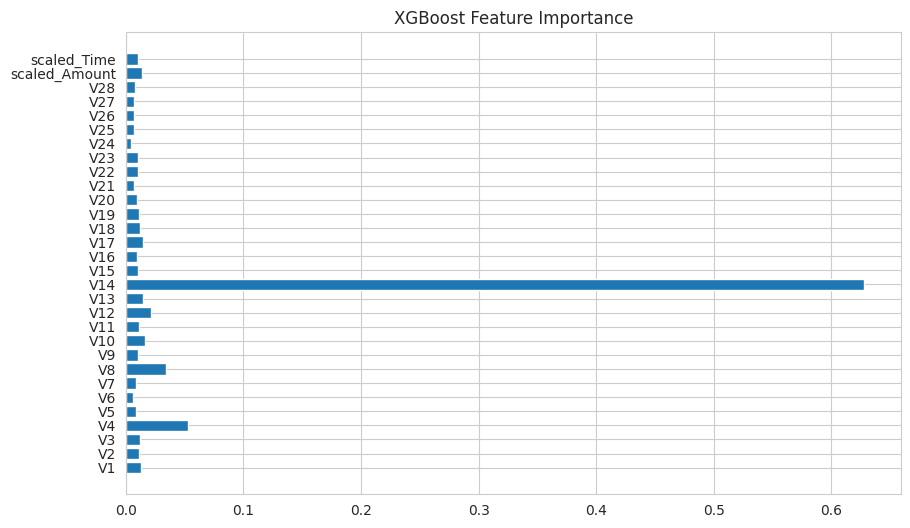


Model Training & Evaluation Completed Successfully!


In [ ]:
plt.figure(figsize=(10,6))
plt.barh(X.columns, xgb.feature_importances_)
plt.title('XGBoost Feature Importance')
plt.show()

print("\nModel Training & Evaluation Completed Successfully!")

In [ ]:
# ---- Save model ----
joblib.dump(model, "fraud_model.pkl")

# ---- Save scaler (important) ----
scaler = StandardScaler()
scaler.fit(X_train)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']